Using Colab cache for faster access to the 'heart-disease-data' dataset.
Starting 5-Fold Cross-Validation...
CV Accuracies: [0.82608696 0.83695652 0.80434783 0.76630435 0.83695652]
Mean Accuracy: 81.41% (+/- 2.67%)

Training final model on all data...
Generating SHAP explanations...


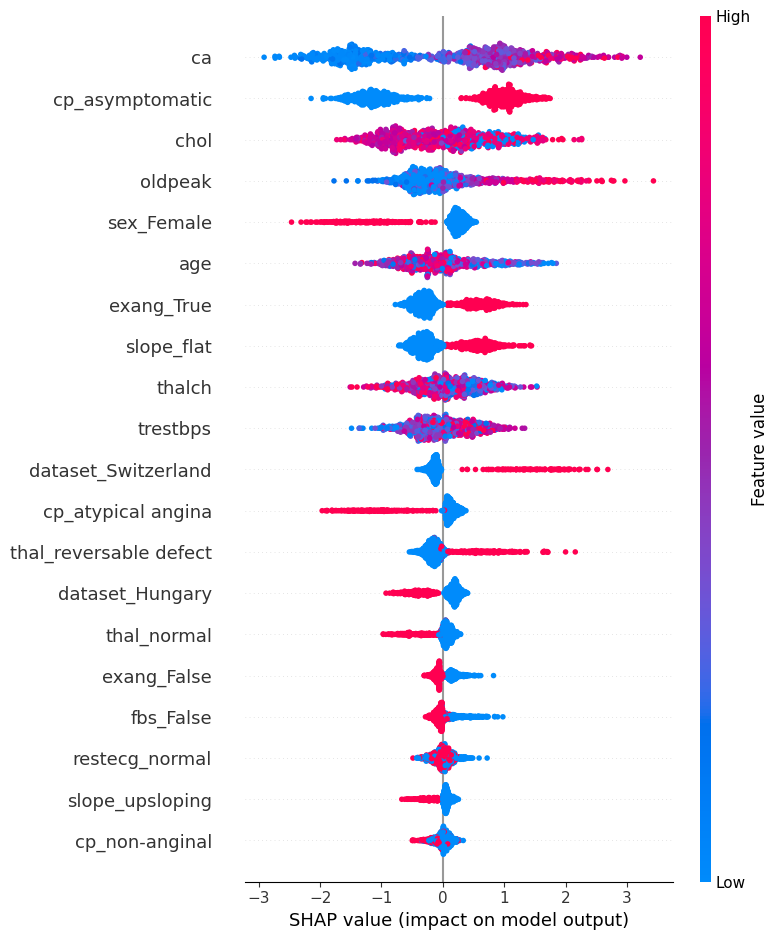

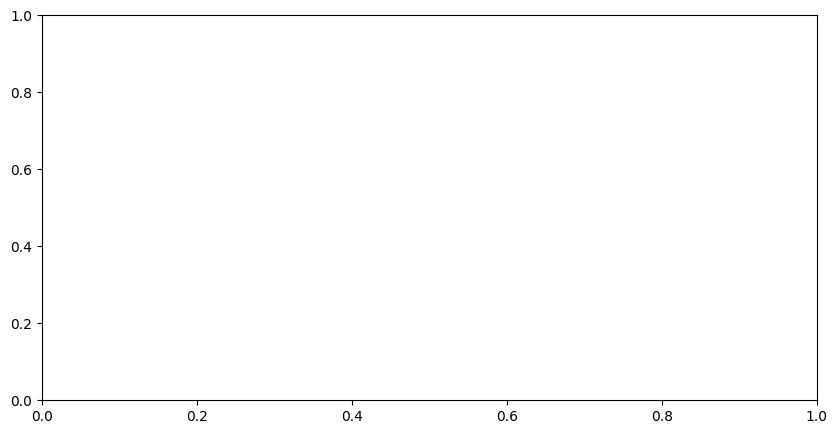

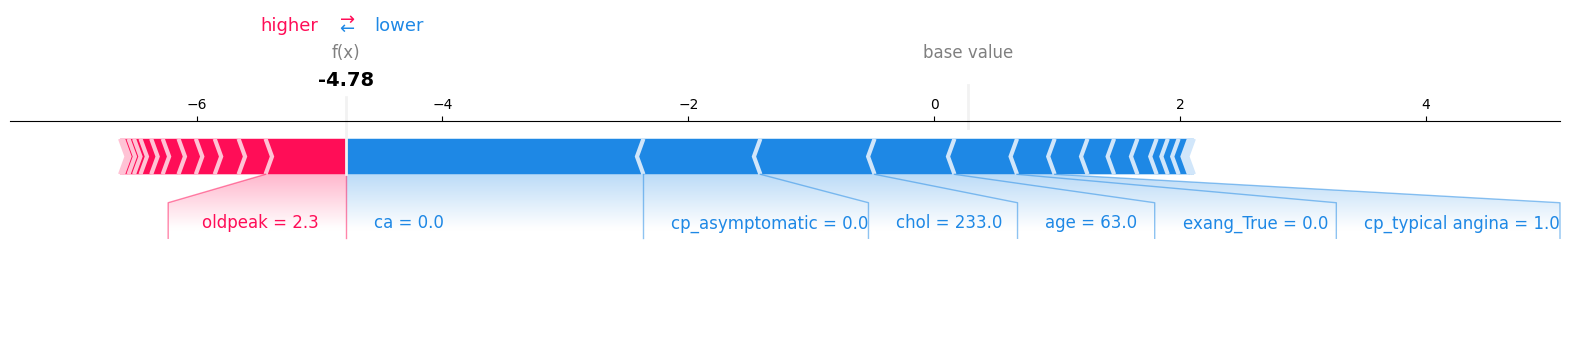


Final Training Accuracy: 100.00%
Ready for Streamlit!


In [2]:
import pandas as pd
import numpy as np
import os
import kagglehub
import joblib
import shap
import matplotlib.pyplot as plt

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# 1. Download and Load Data
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")
csv_file_path = os.path.join(path, 'heart_disease_uci.csv')
df = pd.read_csv(csv_file_path)

# 2. Target Variable Cleaning
df.replace('?', np.nan, inplace=True)
df['target'] = (df['num'] > 0).astype(int)
df.drop(['num', 'id'], axis=1, inplace=True, errors='ignore')

# 3. One-Hot Encoding
categorical_cols = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
df_encoded = pd.get_dummies(df, columns=[c for c in categorical_cols if c in df.columns], dummy_na=False)
X = df_encoded.drop('target', axis=1).astype(float)
y = df_encoded['target']

# Save columns for Streamlit
joblib.dump(X.columns.tolist(), 'model_columns1.joblib')

# 4. Define the Pipeline
# This "packages" the imputer and the model together
heart_pipeline = Pipeline([
    ('imputer', IterativeImputer(random_state=42, max_iter=10)),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'))
])

# 5. K-Fold Cross-Validation
# We do this BEFORE the final training to see how robust the model is
print("Starting 5-Fold Cross-Validation...")
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(heart_pipeline, X, y, cv=kf, scoring='accuracy')

print(f"CV Accuracies: {cv_results}")
print(f"Mean Accuracy: {cv_results.mean():.2%} (+/- {cv_results.std():.2%})")

# 6. Final Training & Saving
# Now we train the pipeline on the ENTIRE dataset for your web app
print("\nTraining final model on all data...")
heart_pipeline.fit(X, y)
joblib.dump(heart_pipeline, 'heart_disease_pipeline.joblib')

# ---------------------------------------------------------
# 7. SHAP Explanations
# ---------------------------------------------------------
# Note: SHAP needs the model and the imputed data.
# We extract them from the pipeline.
final_model = heart_pipeline.named_steps['classifier']
X_imputed_all = heart_pipeline.named_steps['imputer'].transform(X)
X_imputed_df = pd.DataFrame(X_imputed_all, columns=X.columns)

print("Generating SHAP explanations...")
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_imputed_all)

# Plot Summary
shap.summary_plot(shap_values, X_imputed_df, show=False)
plt.show()

# Plot Force Plot (Patient 0)
fig, ax = plt.subplots(figsize=(10, 5))
shap.force_plot(explainer.expected_value, shap_values[0, :], X_imputed_df.iloc[0,:], matplotlib=True, show=False)
plt.show()

# 8. Quick Check
y_pred = heart_pipeline.predict(X)
print(f"\nFinal Training Accuracy: {accuracy_score(y, y_pred):.2%}")
print("Ready for Streamlit!")

In [3]:
%%writefile heart_app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np
import shap
import matplotlib.pyplot as plt

# 1. Page Configuration for Responsiveness
st.set_page_config(
    page_title="Heart AI",
    page_icon="🏥",
    layout="centered" # 'centered' often looks more professional across both mobile and desktop
)

# Custom CSS to make the app look better on mobile
st.markdown("""
    <style>
    .main {
        padding: 1rem;
    }
    .stMetric {
        background-color: #f0f2f6;
        padding: 10px;
        border-radius: 10px;
    }
    </style>
    """, unsafe_markdown=True)

# 2. Load the Pipeline & Columns
@st.cache_resource # Speeds up the app by keeping the model in memory
def load_assets():
    pipeline = joblib.load('heart_disease_pipeline.joblib')
    columns = joblib.load('model_columns1.joblib')
    return pipeline, columns

try:
    pipeline, model_columns = load_assets()
    model = pipeline.named_steps['classifier']
    imputer = pipeline.named_steps['imputer']
except Exception as e:
    st.error("Model files not found. Please run the training script first.")
    st.stop()

# 3. Header
st.title(" Cardiac Risk Assistant")
st.write("Complete the clinical profile below to assess cardiovascular risk.")

# 4. Input Section (Using Columns - these automatically stack on mobile!)
with st.container():
    st.subheader("Patient Vitals")
    col1, col2 = st.columns(2)

    with col1:
        age = st.number_input("Age", 1, 110, 45)
        sex = st.selectbox("Sex", ["male", "female"])
        trestbps = st.number_input("Resting BP (mm Hg)", 80, 200, 120)
        chol = st.number_input("Cholesterol (mg/dl)", 100, 500, 200)

    with col2:
        cp = st.selectbox("Chest Pain", ["typical angina", "atypical angina", "non-anginal", "asymptomatic"])
        fbs = st.selectbox("Fasting Blood Sugar > 120", ["false", "true"])
        thalach = st.number_input("Max Heart Rate", 60, 220, 150)
        oldpeak = st.slider("ST Depression", 0.0, 6.0, 1.0)
        exang = st.selectbox("Exercise Angina", ["false", "true"])

# 5. Prediction Logic
st.markdown("---")
if st.button("Generate Risk Assessment", use_container_width=True): # 'use_container_width' makes button full-width on mobile

    # Prepare data
    input_dict = {
        'age': age, 'trestbps': trestbps, 'chol': chol, 'thalach': thalach, 'oldpeak': oldpeak,
        f'sex_{sex}': 1, f'cp_{cp}': 1, f'fbs_{fbs}': 1, f'exang_{exang}': 1
    }

    input_df = pd.DataFrame(0, index=[0], columns=model_columns)
    for col, val in input_dict.items():
        if col in input_df.columns:
            input_df[col] = val

    # Predict
    prob = pipeline.predict_proba(input_df)[0][1]

    # Responsive Result Display
    res_col1, res_col2 = st.columns(2)
    with res_col1:
        st.metric("Risk Probability", f"{prob:.1%}")
    with res_col2:
        risk_level = "High" if prob > 0.5 else "Low"
        st.metric("Assessment", risk_level)

    if prob > 0.5:
        st.warning(" High Risk detected. Clinical consultation recommended.")
    else:
        st.success(" Low Risk profile based on current metrics.")

    # 6. Explainability (Tucked in an Expander for Mobile)
    with st.expander("View Clinical Reasoning (SHAP Analysis)"):
        st.write("This plot shows how each factor contributed to the current risk score.")

        input_imputed = imputer.transform(input_df)
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(input_imputed)

        # Adjusting figure size for smaller screens
        fig, ax = plt.subplots(figsize=(8, 4))
        shap.force_plot(
            explainer.expected_value,
            shap_values[0,:],
            input_df.iloc[0,:],
            matplotlib=True,
            show=False,
            text_rotation=45 # Rotated text for better narrow-screen fit
        )
        st.pyplot(fig)
        plt.close()

Writing heartapp2.py


In [ ]:
# 1. Clean up old processes
!fuser -k 8501/tcp
!pkill streamlit

# 2. Install Cloudflared
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

# 3. Launch Streamlit in the background
import os
from IPython import get_ipython
get_ipython().system_raw('streamlit run heartapp1.py --server.enableCORS false --server.enableXsrfProtection false &')

# 4. Create the Tunnel (This will generate a link immediately)
print("--- GENERATING SECURE CLOUDFLARE LINK ---")
!cloudflared tunnel --url http://localhost:8501

Selecting previously unselected package cloudflared.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...
--- GENERATING SECURE CLOUDFLARE LINK ---
2026-04-01T19:14:59Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-04-01T19:14:59Z INF Requesting new quick Tunnel on t